# Trabajo Semanal N°5 : 'Estimacion Espectral: Ancho de Banda de Señales Reales'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026


En el siguiente trabajo se llevara a cabo un proceso para determinar como se distribuye la energia de determinadas señales en funcion de la frecuencia. Para esto, se utilizaron 4 señales reales: 
- ECG- Electrocardiograma
- PPG - Fotopletismografia
- Audio: 'La Cucaracha'

Se diseño un codigo para aplicarles el metodo de Welch, y asi poder calcular su Ancho de Banda entre percentiles. Es decir, entre que frecuencias se encuentra un determinado porcentaje de energia acumulada.

La estimacion espectral mediante el Metodo Welch, permite obtener una representacion mas estable del contenido frecuencial de una señal, reduciendo la varianza inherente al periodograma clasico. Su procedimiento, se basa en dividir la señal e multiples segmentos, aplicarle una ventana a cada uno para mitigar la fuga espectral, calcular la transformada rapida de Foourier, y promediar los espectros resultantes. En el codigo se implementa de la siguiente manera: ingresa una señal, y se la divide en una determinada catidad de segmento *cant_promedio*, que sera una de las variables que funcione como *perilla*. Mayor sea la cantidad de promedios, menor sera la varianza, pero si se lo aumenta demasiado, se puede distorcionar la informacion de la señal, modificando la ubicacion de los picos de enrgia o perdiendo demasiados detalles. *nperseg* representa la cantidad de muestras por segmento, se calcula como *N* total sobre la cantidad de promedios, se busco que tenga un valor minimo de 1500 muestras. La segunda variable importante, *mult_nfft*, que representa el factor ue multiplica el largo de la señal,luego de agregarlo el zero-padding. Por ejemplo, si *mult_nfft*$ = 4$, el largo de la señal, post zero-padding, sera 4 veces mayor al original. Este factor, mejora la interpolacion espectral y permite una visualizacion mas detallada del espectro, sin alterar la resolucion real. La tercer variable, sera la eleccion de una ventana *win* para atenuar los extremos de los segmentos sin perder la definicion de los picos de energia. Para el analisis de cada señal, se bucaron valores de los parametro que permitan el equilibrio justo entre la estabilidad estadistica y la fidelidad espectral, para asi poder definir el ancho de banda efectivo. 

El ancho de banda efectivo, se definio como el rango espectral que contiene el 99% de la energia de la señal. Este criterio es util para caracterizar señales con contenido espectral disperso, ya que permite cuantificar la concentracion energetica sin depender de umbrales fijos como el de 3dB. Para aplicarlo al codigo, se desarrollo una funcion que opera sobre la estimacion espectral obtenida en el Metodo Welch. Primero se construye la curva de energia acumulada de la señal, con la funcion *np.cumsum*, y se la divide por la energia total: el ultimo objeto del vector. asi se obtiene la energia total normalizada, *pot_norm*, una funcioncreciente entre 0 y 1, que representa la proporcion acumulada de energia. Para definir la frecuencia minima y maxima, se interpola la frecuencia correposdiente a los limites de energia dispuestos, y se busca el indice asociado en el vector de frecuencias, se grafican con lineas de guiones rojas, se calcula el ancho de banda como la resta entre la frecuencia correspondiente al 99% y la frecuencia que indica el 0.5%. Por ultimo, se presenta una tabla con sus valores. 

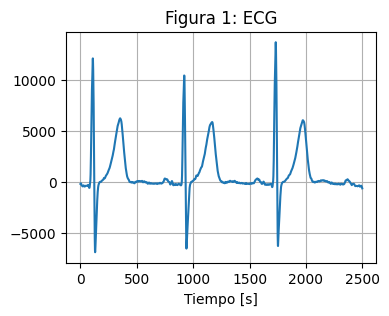

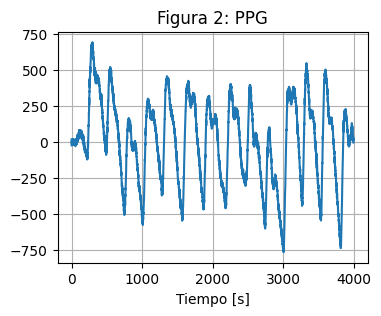

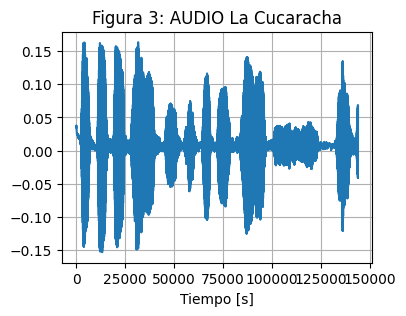

In [8]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio

## FUNCION BW
def BW(f_welch, pxx_welch, cota_inf=0.005, cota_sup=0.99):
    
    pot_tot = np.sum(pxx_welch)
    potencia_normalizada = np.cumsum(pxx_welch) / pot_tot
    fmin = np.where(potencia_normalizada >= cota_inf)[0][0]
    fmax = np.where(potencia_normalizada >= cota_sup)[0][0]
    frec_min = f_welch[fmin]
    frec_max = f_welch[fmax]
    bw = frec_max - frec_min
    return frec_min, frec_max, bw

#########################
# Lectura de ECG + graf #
#########################
fs_ecg = 1000 # Hz
ecg = np.load('./pdstestbench/ecg_sin_ruido.npy')
N_ecg =  len(ecg)
df_ecg = fs_ecg / N_ecg
plt.figure(figsize=(4, 3))
plt.plot(ecg[5000:7500])
plt.title('Figura 1: ECG')
plt.xlabel('Tiempo [s]')
plt.grid(True)
plt.show()

#%%
##########################
# Lectura de PPG + graf  #
##########################

fs_ppg = 400 # Hz
ppg = np.load('./pdstestbench/ppg_sin_ruido.npy')
N_ppg = len(ppg)
df_ppg = fs_ppg / N_ppg

plt.figure(figsize=(4, 3))
plt.plot(ppg[2500:6500])
plt.title('Figura 2: PPG')
plt.xlabel('Tiempo [s]')
plt.grid(True)
plt.show()

#%%
###########################
# Lectura de audio + graf #
###########################

# Cargar el archivo CSV como un array de NumPy
fs_audio, wav_data = sio.wavfile.read('./pdstestbench/la cucaracha.wav')
N_audio = len(wav_data)
df_audio = fs_audio / N_audio

plt.figure(figsize=(4, 3))
plt.plot(wav_data)
plt.title('Figura 3: AUDIO La Cucaracha')
plt.xlabel('Tiempo [s]')
plt.grid(True)
plt.show()

Las lineas de codigo superiores, se encargan de la lectura de los archivos y la impresion de los graficos. A continuacion, se aplica el Metdo *Welch* a cada señal, definiendo de manera personalizada las variables ya explicadas. En los graficos se agrega como una linea punteada roja, las cotas inferiores y superiores del Ancho de Banda, calculados por la funcion *BW*. Tambien, se le realiza un zoom a los graficos que proyectan solo las zonas de interes.

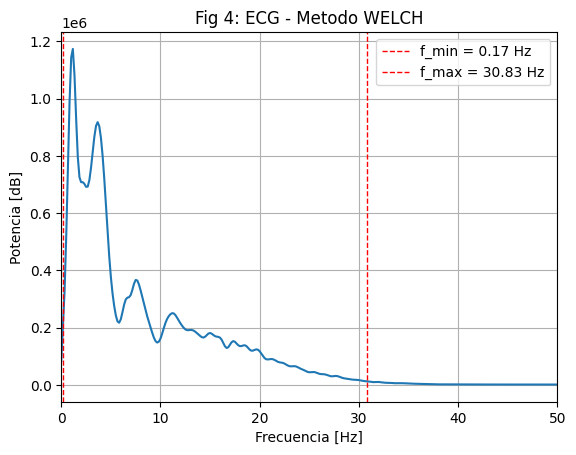

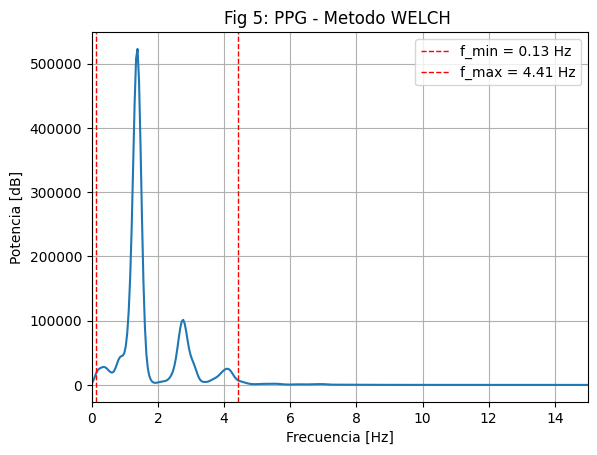

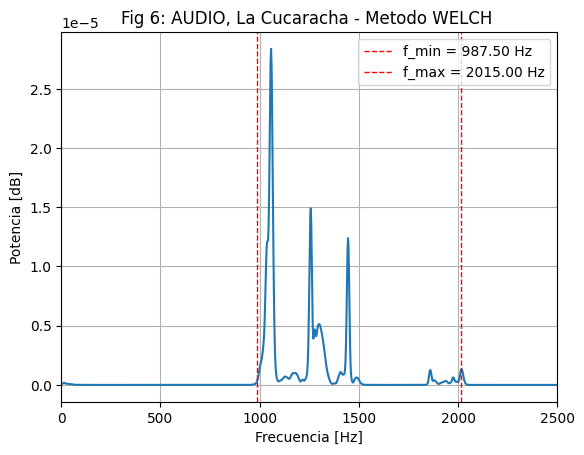

In [5]:
#------------------------ DEF WELCH---------------------------------------------#
## WELCH ECG
cant_promedio1 = 20
nperseg1 = ecg.shape[0]// cant_promedio1
win1 = 'hamming'
mult_nfft = 4
f_welch1, pxx_welch1 = sig.welch(ecg, fs_ecg, nperseg= nperseg1, window= win1, axis = 0, nfft = mult_nfft * nperseg1)

## WELCH PPG
ppg_fft = np.fft.fft(ppg, axis = 0) /N_ppg
nperseg2 = ppg.shape[0] // cant_promedio1
win2 = 'hann'
f_welch2, pxx_welch2 = sig.welch(ppg, fs_ppg, nperseg= nperseg2, axis=0, window= win1,  nfft = mult_nfft * nperseg2)

## WELCH AUDIO
cant_promedio3 = 30
nperseg3 = wav_data.shape[0] // cant_promedio3
win3 = 'bartlett'
f_welch3, pxx_welch3 = sig.welch(wav_data, fs_audio, nperseg= nperseg3, axis=0, window= win3, nfft =mult_nfft * nperseg3)

#%% PUNTO DOS: 
frec_min1, frec_max1, bw_ecg = BW(f_welch1, pxx_welch1)
frec_min2, frec_max2, bw_ppg = BW(f_welch2, pxx_welch2, cota_sup = 0.98)
frec_min3, frec_max3, bw_audio = BW(f_welch3, pxx_welch3)

#%% GRAFICOS  
plt.figure()
plt.plot(f_welch1, pxx_welch1)
plt.title('Fig 4: ECG - Metodo WELCH')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(0,50)
plt.axvline(x=frec_min1, color='red', linestyle='--', linewidth=1, label=f'f_min = {frec_min1:.2f} Hz')
plt.axvline(x=frec_max1, color='red', linestyle='--', linewidth=1, label=f'f_max = {frec_max1:.2f} Hz')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(f_welch2, pxx_welch2)
plt.title('Fig 5: PPG - Metodo WELCH ')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(0,15)
plt.axvline(x=frec_min2, color='red', linestyle='--', linewidth=1, label=f'f_min = {frec_min2:.2f} Hz')
plt.axvline(x=frec_max2, color='red', linestyle='--', linewidth=1, label=f'f_max = {frec_max2:.2f} Hz')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(f_welch3, pxx_welch3)
plt.title('Fig 6: AUDIO, La Cucaracha - Metodo WELCH ')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.xlim(0, 2500)
plt.axvline(x=frec_min3, color='red', linestyle='--', linewidth=1, label=f'f_min = {frec_min3:.2f} Hz')
plt.axvline(x=frec_max3, color='red', linestyle='--', linewidth=1, label=f'f_max = {frec_max3:.2f} Hz')
plt.legend()
plt.grid(True)
plt.show() 

La Figura 4, la estimacion espectral mediante metodo de welch de la señal de ECG, se observa una concentracion de energia en frecuencias bajas, con una caida progresiva hacia los 40Hz. Esta representacion fue construida definiendo 20 segmentos de 1500 muestras, aplicandole un zero-padding de 4 veces su longitud y ventaneando con Hamming, que permitieron reducir la varianza y obtener una curva mas estable. Los valores de frecuencias del ancho de banda parecen ser coherente con la fisiologia cardiaca, donde los componenetes mas significativos se concentran en las zonas:
- **Frecuencia Fundamental**  $\approx$1Hz 
- **Ondas P y T** = [0.5 ; 10] Hz
- **Onda QRS** = [5 ; 40] Hz 

La Figura 5 presenta la estimacion del PPG. Para esta, se definieron 20 segmentos con un largo de 2245 muestras, un zero-padding de *mult_nfft2 = 4* y la ventana Hann. Lo que permitio reducir la varianza espectral y una representacion mas estable del contenido frecuencial. La señal presenta su picos dominantes en los valores aproximados de $1.25Hz$ y  $2.75Hz$. A diferencia de las demas señales, se uso como limite superior el 98%, porque, si se usaba hasta el 99%, se incluian frecuencias con valores que no aportaban a la caracterizacion del ancho de banda efectivo. El rango resultante, es coherente con la naturaleza pulsatil de la señal PPG, donde la frecuencia cardiaca y sus armonicos suelen concentrarse por debajo de los $5Hz$. Siendo al rededor de los 1.5Hz su pido principal, en 3Hz su segundo armonico y cerca de los 4.5Hz su tercer armonico. 

Para la señal de audio, Figura 6, se definieron 30 segmentos, de 4800 muestras y se les aplico la ventana 'Bartlette'. La estimacion revela multiples picos bien definidos entre los [1000;1500]Hz y un grupo mas pequeño cercano a los 2000Hz. Lo cual, refleja adecuadamente a la voz humana, donde las frecuencias fundamentales suelen estar entre los 100Hz y 3kHz aproximadamente. Ademas, fuera del rango la potencia es practiamente cero, lo que indica una estimacion limpia.

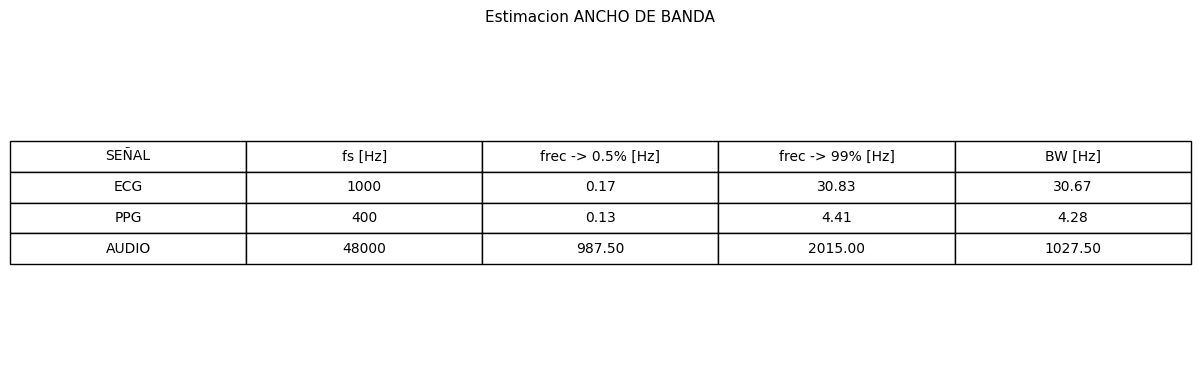

In [6]:
## TABLA
##Crear tabla con los encabezados fijos
tabla = [
    ["SEÑAL",   "fs [Hz]",   "frec -> 0.5% [Hz]",  "frec -> 99% [Hz]",  "BW [Hz]"],
    ["ECG", fs_ecg, f"{frec_min1:.2f}", f"{frec_max1:.2f}", f"{bw_ecg:.2f}"],
    ["PPG", fs_ppg, f"{frec_min2:.2f}", f"{frec_max2:.2f}", f"{bw_ppg:.2f}"],
    ["AUDIO", fs_audio, f"{frec_min3:.2f}", f"{frec_max3:.2f}", f"{bw_audio:.2f}"],
]

# Mostrar como imagen
fig, ax = plt.subplots(figsize=(12, 2 + len(tabla)*0.5))
ax.axis('tight')
ax.axis('off')
plt.title("Estimacion ANCHO DE BANDA", fontsize=11, pad=1)
table = ax.table(cellText=tabla, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
plt.tight_layout()
plt.show()

Por ultimo, se presenta una tabla con las frecuencias, las cotas inferiores y superiores  y el ancho de banda para cada una de las señales.
El ECG presenta un ancho de banda de 30.67Hz, concentrado entre los [0.17; 30.83]Hz. Lo que tiene sentido fisiologico por que la señal cardiaca contiene componentes de bajas frecuencias correspondientes a su forma de onda. 

El PPG muestra un Ancho de banda de: 5.3Hz, bastanet mas acotado, entre los valores [0.13;5.43]Hz. esto es esperable, ya que mide variaciones en el volumen sanguineo, se limita a la frecuencia cardiaca fundamental ue existe aproximadamente en los 1.5Hz. Al no contener la onda QRS, sus frecuencias tieneden a ser considerablemente mas bajas. 

La señal de audio, presenta un comportamiento distintos a las señales biologicas. Sus frecuencias limite son 987.5Hz y 2015Hz, con un ancho de banda de 1027.5Hz. Esto refleja las caracteristicas de la voz humana cantada, cuyas frecuencias fundamentales se concentran en el rango de los 1000 a 2000 Hz.

A lo largo de este trabajo se aplico el Metodo de Welch para la estimacion de señales biologicas distintas: fisiologicas, el ECG y PPG, y acusticas, la voz. Se implementaron criterios de energia acumulada para definir el ancho de banda efectivo permitiendo identificar el rango de frecuencias que concentra la energia que caracteriza a la señal. La parametrizacion cuidadosa de los parametros del metodo Welch, permitieron controlar el balance entre la varianza espectral y la definicion de picos, optimizando la interpreteacion en cada caso. En la señal ECG, el BW se concentro por debajo de los $40Hz$, reflejando la fisiologia cardiaca, para el PPG, se observo una concentracion entre los $0.5Hz$ y los $4Hz$, coherente con la dinamica pulsatil y la señal de audio entre los $1kHz$ y $2kHz$ como se espera de la voz humana. Estos resultados validan la utilidad del metodo de Welch y el enfoque acumulativo de energia. 